In [1]:
import geopandas as gpd
import pandas as pd
import plotly.express as px
import fiona

In [12]:
# read in file 
schools = gpd.read_file("../Schools/texas_private_schools.geojson")
schools_and_grades = pd.read_csv("../Schools/private_schools_grades.csv")

In [ ]:
# dallas county schools data
# not currently necessary, but saving for later just in case

# counties = gpd.read_file("../Schools/tx_counties.topojson", engine = "fiona").set_crs("EPSG:4326")
# dallas_county = counties[counties['COUNTY'] == "Dallas County"]['geometry'].iloc[0]
# schools_bool = schools.geometry.within(dallas_county)
# schools = schools[schools_bool]

In [3]:
# filter to only include schools in dallas county
dallas_schools = schools[schools["County"] == "DALLAS"]

In [4]:
# indicates whether or not a school accepts tefa
# 1 indicates yes, 0 indicates no
vouchers = [1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 
            0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 
            0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 
            1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 
            1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 
            0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 
            1, 1, 1, 0, 0, 1, 1, 0, 0]

# adds indicator column to df
dallas_schools["Voucher"] = vouchers

# filters to only include schools that accept vouchers
voucher_schools = dallas_schools[dallas_schools["Voucher"] == 1]

/users/mpietraho/.local/lib/python3.11/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [5]:
voucher_schools.head()

,OBJECTID,Name,Tuition,Enrollment,PreK,Total,Address,City,State,Zip,County,Latitude,Longitude,GeoScore,GeoAddress,GeoRank,Grades,GlobalID,geometry,Voucher
237,238,AKIBA ACADEMY OF DALLAS,0,237,114,351,12324 MERIT DR,DALLAS,TX,75251,DALLAS,32.915445,-96.771912,100.0,"12324 Merit Dr, Dallas, Texas, 75251",20.0,,{3E5871A5-CEA8-4566-9163-FA593B0C4EB7},POINT (-96.77191 32.91544),1
239,240,ADVANCED PREPARATORY INTERNATIONAL,0,26,0,26,5787 S HAMPTON RD STE 115,DALLAS,TX,75232,DALLAS,32.677224,-96.857184,100.0,"5787 S Hampton Rd, Dallas, Texas, 75232",20.0,,{0AA3417E-9D0F-46FC-B7DE-F9D1E826A25C},POINT (-96.85718 32.67722),1
240,241,APPLESEED ACADEMY,0,16,64,80,4346 N GALLOWAY AVE,MESQUITE,TX,75150,DALLAS,32.822789,-96.620740,100.0,"4346 N Galloway Ave, Mesquite, Texas, 75150",20.0,,{23FB3E08-2181-46B7-BDBC-382FDC20604D},POINT (-96.62074 32.82279),1
243,244,ARBORCREEK MONTESSORI SCHOOL,0,17,29,46,2713 COOKSCREEK PL,FARMERS BRANCH,TX,75234,DALLAS,32.941297,-96.888850,100.0,"2713 Cookscreek Pl, Dallas, Texas, 75234",20.0,,{B3CFBA6C-C2D1-4579-80ED-6A8F5FA4A006},POINT (-96.88885 32.9413),1
245,246,BISHOP DUNNE CATHOLIC SCHOOL,15000,611,0,613,3900 RUGGED DR,DALLAS,TX,75224,DALLAS,32.695539,-96.851976,100.0,"3900 Rugged Dr, Dallas, Texas, 75224",20.0,6-12,{758A1CE8-BD07-4A81-8434-0329DDFCA5BF},POINT (-96.85198 32.69554),1


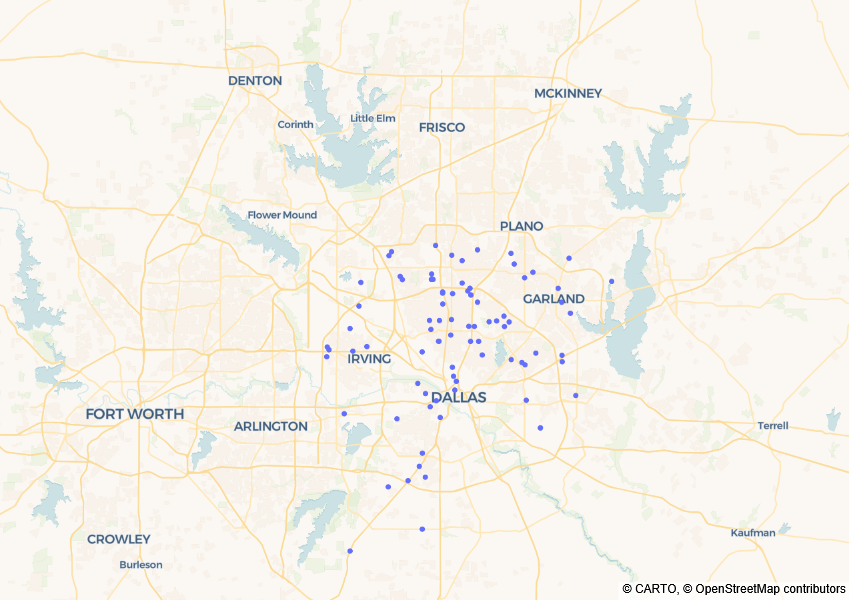

In [26]:
# plots all schools that accept the voucher
fig = px.scatter_map(
    voucher_schools, 
    lat="Latitude", 
    lon="Longitude", 
    hover_name="Name",
    zoom=9, 
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0, "t":0, "l":0, "b":0})

fig.show()

In [15]:
voucher_schools.head()

,OBJECTID,Name,Tuition,Enrollment,PreK,Total,Address,City,State,Zip,County,Latitude,Longitude,GeoScore,GeoAddress,GeoRank,Grades,GlobalID,geometry,Voucher
237,238,AKIBA ACADEMY OF DALLAS,0,237,114,351,12324 MERIT DR,DALLAS,TX,75251,DALLAS,32.915445,-96.771912,100.0,"12324 Merit Dr, Dallas, Texas, 75251",20.0,,{3E5871A5-CEA8-4566-9163-FA593B0C4EB7},POINT (-96.77191 32.91544),1
239,240,ADVANCED PREPARATORY INTERNATIONAL,0,26,0,26,5787 S HAMPTON RD STE 115,DALLAS,TX,75232,DALLAS,32.677224,-96.857184,100.0,"5787 S Hampton Rd, Dallas, Texas, 75232",20.0,,{0AA3417E-9D0F-46FC-B7DE-F9D1E826A25C},POINT (-96.85718 32.67722),1
240,241,APPLESEED ACADEMY,0,16,64,80,4346 N GALLOWAY AVE,MESQUITE,TX,75150,DALLAS,32.822789,-96.620740,100.0,"4346 N Galloway Ave, Mesquite, Texas, 75150",20.0,,{23FB3E08-2181-46B7-BDBC-382FDC20604D},POINT (-96.62074 32.82279),1
243,244,ARBORCREEK MONTESSORI SCHOOL,0,17,29,46,2713 COOKSCREEK PL,FARMERS BRANCH,TX,75234,DALLAS,32.941297,-96.888850,100.0,"2713 Cookscreek Pl, Dallas, Texas, 75234",20.0,,{B3CFBA6C-C2D1-4579-80ED-6A8F5FA4A006},POINT (-96.88885 32.9413),1
245,246,BISHOP DUNNE CATHOLIC SCHOOL,15000,611,0,613,3900 RUGGED DR,DALLAS,TX,75224,DALLAS,32.695539,-96.851976,100.0,"3900 Rugged Dr, Dallas, Texas, 75224",20.0,6-12,{758A1CE8-BD07-4A81-8434-0329DDFCA5BF},POINT (-96.85198 32.69554),1


In [13]:
schools_and_grades.head()

,School Name,School Number,Closed,School Street,School City,School Zip,Grade Low,Grade High,Enrollment,School Accreditations,District Name,District Number,District Enrollment,District Street,District City,District Zip,County Name,County Number,Region Name
0,Akiba Yavneh Academy of Dallas,57187101,False,12324 Merit Drive,Dallas,75251,Pre-K,12,425,COGNIA : 1992 | TAAPS : 1998,DALLAS ISD,57905.0,158932,3700 ROSS AVE,DALLAS,75204-5491,Dallas,57,10.0
1,Alcuin School,57203101,False,6144 Churchill Way,Dallas,75230,Pre-K,12,635,ISAS : 1999 | ISAS : 2009 | ISAS : 2019,DALLAS ISD,57905.0,158932,3700 ROSS AVE,DALLAS,75204-5491,Dallas,57,10.0
2,Ann and Nate Levine Academy - A Solomon Schech...,57147101,False,18011 Hillcrest Rd,Dallas,75252,Pre-K,8,443,ISAS : 2022,DALLAS ISD,57905.0,158932,3700 ROSS AVE,DALLAS,75204-5491,Dallas,57,10.0
3,ArborCreek Montessori Academy,57440001,False,13310 Bee Street,Farmers Branch,75234,1,6,16,COGNIA : 2025,DALLAS ISD,57905.0,158932,3700 ROSS AVE,DALLAS,75204-5491,Dallas,57,10.0
4,BASIS Richardson,57430001,True,2200 North Greenville Avenue,Richardson,75082,6,7,102,COGNIA : 2025,RICHARDSON ISD,57916.0,38043,400 S GREENVILLE AVE,RICHARDSON,75081-4198,Dallas,57,10.0
